In [2]:
import pandas as pd
import os
import re

AA_dict = {"Ala":'A',
                  "Arg":'R',
                  "Asn":'N',
                  "Asp":'D',
                  "Cys":'C',
                  "Glu":'E',
                  "Gln":'Q',
                  "Gly":'G',
                  "His":'H',
                  "Ile":'I',
                  "Leu":'L',
                  "Lys":'K',
                  "Met":'M',
                  "Phe":'F',
                  "Pro":'P',
                  "Ser":'S',
                  "Thr":'T',
                  "Trp":'W',
                  "Tyr":'Y',
                  "Val":'V'}

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [48]:
OUTPUT_DIR = "ClinVar_By_UniProt"
files = os.listdir(OUTPUT_DIR)
clinvar_sig = [
    'Benign',
    'Likely benign',
    'Likely pathogenic',
    'Pathogenic',
    'Likely pathogenic, low penetrance',
    'Pathogenic, low penetrance',
    'Likely risk allele'
]
type_conseqeunce = ['single nucleotide variant']

with open('clinvar_SNV_human.txt','w') as mutfile:
    for file in files:
        if file.endswith('.txt'):
            input_file = OUTPUT_DIR+'/'+file
            df = pd.read_csv(input_file, sep='\t',low_memory=False)
            uid, gene, ext = file.split('_')
            print(file, uid)
    
            # filter
            df_filt = df[
                (df['Type'].isin(type_conseqeunce)) &
                (df['ClinicalSignificance'].isin(clinvar_sig))].copy()
            
             # Exit if protein_change column is entirely NaN
            if df['protein_change'].notna().sum() == 0:
                print("No protein_change entries found. Exiting.")
                mutant_positions = []
            else:
        
                # regex for missense changes
                missense_pattern = r'^p\.([A-Za-z]{3})(\d+)([A-Za-z]{3})$'
                
                # Extract only from non-null values
                extracted = df_filt['protein_change'].str.extract(missense_pattern)
                
                # Keep rows where extraction succeeded
                mask = extracted.notna().all(axis=1)
                
                df_filt = df_filt.loc[mask].copy()
                
                # keep only valid missense variants
                df_filt = df_filt[
                    df_filt['protein_change'].fillna('').str.match(missense_pattern) ].copy()
                
                # extract WT AA, position, MUT AA
                df_filt[['wt_aa', 'position', 'mut_aa']] = (
                    df_filt['protein_change']
                    .str.extract(missense_pattern))
                
                df_filt['position'] = df_filt['position'].astype(int)
                
                # optional: remove synonymous variants
                df_filt = df_filt[df_filt['wt_aa'] != df_filt['mut_aa']]

                # map single letter muattion 
                df_filt['wt1'] = df_filt['wt_aa'].map(AA_dict)
                df_filt['mut1'] = df_filt['mut_aa'].map(AA_dict)
                
                df_filt['mutation'] = (
                    df_filt['wt1'] +
                    df_filt['position'].astype(str) +
                    df_filt['mut1']
                )

                # print(mutations)
                mutations = (df_filt['mutation'].unique())
                mutations_clean = [m for m in mutations if pd.notna(m)]

                mutation_string = ",".join(mutations_clean)
                # print(mutation_string)

                # list of mutant positions
                mutant_positions = sorted(df_filt['position'].unique())
          
                mutfile.write(uid+'\t'+gene+'\t'+ mutation_string +'\n')
            


Q9H6F5_CCDC86_clinvar.txt Q9H6F5
Q8TEP8_CEP192_clinvar.txt Q8TEP8
Q8N4N8_KIF2B_clinvar.txt Q8N4N8
Q9BUB4_ADAT1_clinvar.txt Q9BUB4
P15907_ST6GAL1_clinvar.txt P15907
A8MW95_BECN2_clinvar.txt A8MW95
Q9BRR0_ZKSCAN3_clinvar.txt Q9BRR0
Q70EL4_USP43_clinvar.txt Q70EL4
Q5T1B0_AXDND1_clinvar.txt Q5T1B0
Q9NXF1_TEX10_clinvar.txt Q9NXF1
Q9BXS4_TMEM59_clinvar.txt Q9BXS4
O94983_CAMTA2_clinvar.txt O94983
Q9ULI3_HEG1_clinvar.txt Q9ULI3
P49427_CDC34_clinvar.txt P49427
P19623_SRM_clinvar.txt P19623
Q9NR30_DDX21_clinvar.txt Q9NR30
Q9NX05_FAM120C_clinvar.txt Q9NX05
Q8IV76_PASD1_clinvar.txt Q8IV76
P98175_RBM10_clinvar.txt P98175
Q15700_DLG2_clinvar.txt Q15700
Q9Y6A5_TACC3_clinvar.txt Q9Y6A5
Q8WVD3_RNF138_clinvar.txt Q8WVD3
P05091_ALDH2_clinvar.txt P05091
Q9H6B1_ZNF385D_clinvar.txt Q9H6B1
Q3KP31_ZNF791_clinvar.txt Q3KP31
Q15008_PSMD6_clinvar.txt Q15008
Q5T5D7_ZNF684_clinvar.txt Q5T5D7
O75695_RP2_clinvar.txt O75695
Q9NU63_ZFP57_clinvar.txt Q9NU63
P15172_MYOD1_clinvar.txt P15172
Q9Y5Y6_ST14_clinvar.txt Q9Y5Y6

In [3]:
dfmut = pd.read_csv('clinvar_SNV_human.txt',sep='\t', header=None)
df_ref = pd.read_csv('homo_sapiens_reference_dataset.csv') #from ProteomeScout
dfmut.columns = ['UID','gene','mutations']
df_cleaned = dfmut.dropna(subset=['mutations'])
df_cleaned.head()

,UID,gene,mutations
0,Q9H6F5,CCDC86,"Q151R,E36Q"
1,Q8TEP8,CEP192,"L111F,P1159R,N1883S,T1053A,N380S,T1547M,R956C,..."
2,Q8N4N8,KIF2B,"R257C,R552C,P490S,T320R,R640Q,Q168L,I26V,R110S..."
3,Q9BUB4,ADAT1,"L319F,N168S,H29R,G272R"
5,A8MW95,BECN2,"I103M,E158K,R243M"


In [4]:
import pandas as pd
import re
from collections import defaultdict

mut_lookup = defaultdict(list)

for _, row in dfmut.iterrows():

    uid = row['UID']

    if pd.isna(row['mutations']):
        continue

    muts = str(row['mutations']).split(',')

    for m in muts:
        m = m.strip()

        # extract position: Q151R -> 151
        match = re.match(r'[A-Za-z](\d+)[A-Za-z]', m)
        if match:
            pos = int(match.group(1))
            mut_lookup[uid].append((pos, m))

In [5]:
results = []

for _, row in df_ref.iterrows():

    uid = row['uniprot_id']

    if uid not in mut_lookup:
        continue

    m = re.fullmatch(r'Y(\d+)', str(row['site']))
    if not m:
        continue

    ptm_pos = int(m.group(1))

    window = set(range(ptm_pos - 2, ptm_pos + 5))
    # window.discard(ptm_pos)

    matching_muts = [
        mut for pos, mut in mut_lookup[uid]
        if pos in window
    ]

    if matching_muts:

        results.append({
            'UID': uid,
            'gene_name': row['gene_name'],
            'site': row['site'],
            'ptm_position': ptm_pos,
            'nearby_mutations': ",".join(matching_muts),
            'oriented_peptide': row['oriented_peptide']
        })

df_ptm_mut = pd.DataFrame(results)

In [6]:
df_ptm_mut

,UID,gene_name,site,ptm_position,nearby_mutations,oriented_peptide
0,Q9H773,DCTPP1,Y129,129,R127Q,MDINRRRyPAHLARS
1,O95154,AKR7A3,Y172,172,I175T,PTVYQGMyNAITRQV
2,O60673,REV3L,Y128,128,M132V,HFMKIYLyNPTMVKR
3,O60673,REV3L,Y1156,1156,Y1156C,LFKGPNVyKKTVNSR
4,Q9Y4W6,AFG3L2,Y614,614,Y616C,QYLPKEQyLYTKEQL
...,...,...,...,...,...,...
5595,P58012,FOXL2,Y186,186,G185R,AGAGADGyGYLAPPK
5596,P58012,FOXL2,Y215,215,S217F,QPPSPMPyASCQMAA
5597,P35658,NUP214,Y1265,1265,S1264F,GGGSKPSyEAIPESS
5598,O15403,SLC16A6,Y224,224,A222V,ENRKEAQyMLENEKT


In [12]:
dfmut.loc[dfmut['UID']=='P58012']['mutations'].values[0]

'I84S,E69K,R349G,S217F,A179G,P267T,K114E,S107G,L106F,H104R,S101R,W98R,M65I,I63L,N100D,P89R,F88I,L77P,I63N,Y59D,S58W,Y57N,K54E,P89Q,S263R,G185R,P205R,F90L,K124E,L75F,A66E,P281T,H104Y,F112C,H104N,I84T,F90S'

In [7]:
mutant_peptides_all = []

for _, row in df_ptm_mut.iterrows():

    pep = row['oriented_peptide']
    muts = row['nearby_mutations']

    if pd.isna(pep) or pd.isna(muts):
        mutant_peptides_all.append(None)
        continue

    try:
        ptm_idx = pep.index('y')  # anchor position
    except ValueError:
        mutant_peptides_all.append(None)
        continue

    pep_list = list(pep)

    mut_list = muts.split(',')
    mutated_seqs = []

    for mut in mut_list:

        if len(mut) < 3:
            continue

        wt_aa = mut[0]
        mut_aa = mut[-1]

        pos = int(''.join([c for c in mut if c.isdigit()]))

        offset = pos - row['ptm_position']
        mut_idx = ptm_idx + offset

        if mut_idx < 0 or mut_idx >= len(pep_list):
            continue

        # optional sanity check
        if pep_list[mut_idx].upper() != wt_aa:
            continue

        tmp = pep_list.copy()
        tmp[mut_idx] = mut_aa

        mutated_seqs.append("".join(tmp))

    mutant_peptides_all.append(";".join(mutated_seqs) if mutated_seqs else None)

# just ADD column (do not modify existing ones)
df_ptm_mut['mutant_peptides'] = mutant_peptides_all

In [8]:
df_ptm_mut

,UID,gene_name,site,ptm_position,nearby_mutations,oriented_peptide,mutant_peptides
0,Q9H773,DCTPP1,Y129,129,R127Q,MDINRRRyPAHLARS,MDINRQRyPAHLARS
1,O95154,AKR7A3,Y172,172,I175T,PTVYQGMyNAITRQV,PTVYQGMyNATTRQV
2,O60673,REV3L,Y128,128,M132V,HFMKIYLyNPTMVKR,HFMKIYLyNPTVVKR
3,O60673,REV3L,Y1156,1156,Y1156C,LFKGPNVyKKTVNSR,LFKGPNVCKKTVNSR
4,Q9Y4W6,AFG3L2,Y614,614,Y616C,QYLPKEQyLYTKEQL,QYLPKEQyLCTKEQL
...,...,...,...,...,...,...,...
5595,P58012,FOXL2,Y186,186,G185R,AGAGADGyGYLAPPK,AGAGADRyGYLAPPK
5596,P58012,FOXL2,Y215,215,S217F,QPPSPMPyASCQMAA,QPPSPMPyAFCQMAA
5597,P35658,NUP214,Y1265,1265,S1264F,GGGSKPSyEAIPESS,GGGSKPFyEAIPESS
5598,O15403,SLC16A6,Y224,224,A222V,ENRKEAQyMLENEKT,ENRKEVQyMLENEKT


In [9]:
df = df_ptm_mut.copy()

df['mutation'] = df['nearby_mutations'].str.split(',')

df = df.explode('mutation')


In [10]:
mutant_peptides = []

for _, row in df.iterrows():

    pep = row['oriented_peptide']
    mut = row['mutation']

    if pd.isna(pep) or pd.isna(mut):
        mutant_peptides.append(None)
        continue

    try:
        ptm_idx = pep.index('y')
    except ValueError:
        mutant_peptides.append(None)
        continue

    wt_aa = mut[0]
    mut_aa = mut[-1]
    pos = int(''.join([c for c in mut if c.isdigit()]))

    offset = pos - row['ptm_position']
    mut_idx = ptm_idx + offset

    pep_list = list(pep)

    if mut_idx < 0 or mut_idx >= len(pep_list):
        mutant_peptides.append(None)
        continue

    if pep_list[mut_idx].upper() != wt_aa:
        mutant_peptides.append(None)
        continue

    pep_list[mut_idx] = mut_aa

    mutant_peptides.append("".join(pep_list))

df['mutant_peptide'] = mutant_peptides
df = df.drop(columns=['mutant_peptides'])


In [11]:
def extract_window(seq):

    if pd.isna(seq):
        return None

    try:
        y_idx = seq.index('y')
    except ValueError:
        return None

    return (
        seq[y_idx-2:y_idx] +
        seq[y_idx+1:y_idx+5]
    )

# df['wt_window'] = df['oriented_peptide'].apply(extract_window)
# df['mut_window'] = df['mutant_peptide'].apply(extract_window)
df['wt_6mer'] = df['oriented_peptide'].apply(extract_window)
df['mut_6mer'] = df['mutant_peptide'].apply(extract_window)
df.head()

,UID,gene_name,site,ptm_position,nearby_mutations,oriented_peptide,mutation,mutant_peptide,wt_6mer,mut_6mer
0,Q9H773,DCTPP1,Y129,129,R127Q,MDINRRRyPAHLARS,R127Q,MDINRQRyPAHLARS,RRPAHL,QRPAHL
1,O95154,AKR7A3,Y172,172,I175T,PTVYQGMyNAITRQV,I175T,PTVYQGMyNATTRQV,GMNAIT,GMNATT
2,O60673,REV3L,Y128,128,M132V,HFMKIYLyNPTMVKR,M132V,HFMKIYLyNPTVVKR,YLNPTM,YLNPTV
3,O60673,REV3L,Y1156,1156,Y1156C,LFKGPNVyKKTVNSR,Y1156C,LFKGPNVCKKTVNSR,NVKKTV,None
4,Q9Y4W6,AFG3L2,Y614,614,Y616C,QYLPKEQyLYTKEQL,Y616C,QYLPKEQyLCTKEQL,EQLYTK,EQLCTK


In [19]:
df.to_csv('Human_pY_clinVar_variants_withpY.csv')

In [12]:
df

,UID,gene_name,site,ptm_position,nearby_mutations,oriented_peptide,mutation,mutant_peptide,wt_6mer,mut_6mer
0,Q9H773,DCTPP1,Y129,129,R127Q,MDINRRRyPAHLARS,R127Q,MDINRQRyPAHLARS,RRPAHL,QRPAHL
1,O95154,AKR7A3,Y172,172,I175T,PTVYQGMyNAITRQV,I175T,PTVYQGMyNATTRQV,GMNAIT,GMNATT
2,O60673,REV3L,Y128,128,M132V,HFMKIYLyNPTMVKR,M132V,HFMKIYLyNPTVVKR,YLNPTM,YLNPTV
3,O60673,REV3L,Y1156,1156,Y1156C,LFKGPNVyKKTVNSR,Y1156C,LFKGPNVCKKTVNSR,NVKKTV,None
4,Q9Y4W6,AFG3L2,Y614,614,Y616C,QYLPKEQyLYTKEQL,Y616C,QYLPKEQyLCTKEQL,EQLYTK,EQLCTK
...,...,...,...,...,...,...,...,...,...,...
5595,P58012,FOXL2,Y186,186,G185R,AGAGADGyGYLAPPK,G185R,AGAGADRyGYLAPPK,DGGYLA,DRGYLA
5596,P58012,FOXL2,Y215,215,S217F,QPPSPMPyASCQMAA,S217F,QPPSPMPyAFCQMAA,MPASCQ,MPAFCQ
5597,P35658,NUP214,Y1265,1265,S1264F,GGGSKPSyEAIPESS,S1264F,GGGSKPFyEAIPESS,PSEAIP,PFEAIP
5598,O15403,SLC16A6,Y224,224,A222V,ENRKEAQyMLENEKT,A222V,ENRKEVQyMLENEKT,AQMLEN,VQMLEN


In [16]:
#extract pY sites that are mutated
import re

# extract mutation position
df["mut_position"] = df["mutation"].str.extract(r'(\d+)').astype(int)

# keep only mutations at the PTM site
df_ptm_site_mut = df[
    df["mut_position"] == df["ptm_position"]
].copy()

df_ptm_site_mut

,UID,gene_name,site,ptm_position,nearby_mutations,oriented_peptide,mutation,mutant_peptide,wt_6mer,mut_6mer,mut_position
3,O60673,REV3L,Y1156,1156,Y1156C,LFKGPNVyKKTVNSR,Y1156C,LFKGPNVCKKTVNSR,NVKKTV,None,1156
22,Q4AC94,C2CD3,Y2064,2064,Y2064C,PAYSDEDyEEDIIEP,Y2064C,PAYSDEDCEEDIIEP,EDEEDI,None,2064
29,Q27J81,INF2,Y1079,1079,Y1079C,LERRSSWyVDASDVL,Y1079C,LERRSSWCVDASDVL,SWVDAS,None,1079
30,P35680,HNF1B,Y169,169,"V173L,W171C,Y169H,W171R",TQKRAALyTWYVRKQ,Y169H,TQKRAALHTWYVRKQ,ALTWYV,None,169
37,Q9UNA4,POLI,Y380,380,Y380C,RYSSEKHyGRESRQC,Y380C,RYSSEKHCGRESRQC,KHGRES,None,380
...,...,...,...,...,...,...,...,...,...,...,...
5560,P40198,CEACAM3,Y95,95,"A93P,Y95N",QATPGAAySGRETIY,Y95N,QATPGAANSGRETIY,AASGRE,None,95
5565,P46063,RECQL,Y61,61,"Y61H,N59S",DAGASNEyDSSPAAW,Y61H,DAGASNEHDSSPAAW,NEDSSP,None,61
5569,Q9UQE7,SMC3,Y669,669,Y669D,GALTGGYyDTRKSRL,Y669D,GALTGGYDDTRKSRL,GYDTRK,None,669
5589,P49768,PSEN1,Y154,154,Y154C,TILLVVLyKYRCYKV,Y154C,TILLVVLCKYRCYKV,VLKYRC,None,154


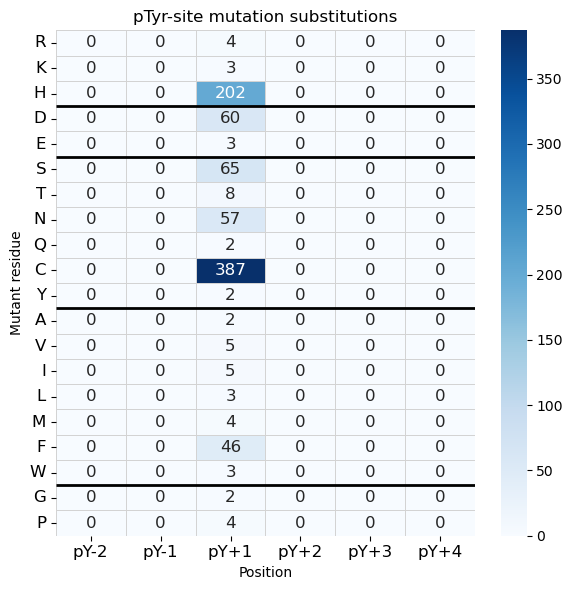

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

aa_order = [
    # Positive
    'R', 'K', 'H',

    # Negative
    'D', 'E',

    # Polar
    'S', 'T', 'N', 'Q', 'C', 'Y',

    # Hydrophobic
    'A', 'V', 'I', 'L', 'M', 'F', 'W',

    # Special
    'G', 'P'
]

df["mut_position"] = df["mutation"].str.extract(r'(\d+)').astype(int)

df_ptm_site_mut = df[df["mut_position"] == df["ptm_position"]].copy() # keep only mutations at the PTM site

df_ptm_site_mut["mut_residue"] = (df_ptm_site_mut["mutation"].str.extract(r'(\d+)([A-Z])$')[1])

mut_counts = (df_ptm_site_mut["mut_residue"].value_counts())

pos_cols = ["pY-2", "pY-1","pY+1","pY+2","pY+3","pY+4" ] # use your existing heatmap columns

mut_heatmap = pd.DataFrame(0,index=aa_order,columns=pos_cols)

if "pY" in mut_heatmap.columns:
    py_col = "pY"
else:
    py_col = mut_heatmap.columns[2]


for aa, count in mut_counts.items():
    if aa in mut_heatmap.index:
        mut_heatmap.loc[aa, py_col] = count

mut_heatmap = mut_heatmap.reindex(aa_order)


plt.figure(figsize=(6,6))

ax = sns.heatmap(
    mut_heatmap,
    cmap="Blues",
    linewidths=0.5,
    linecolor="lightgray",
    annot=True,
    fmt="d",
    annot_kws={"fontsize":12},
    cbar=True)

x_label_map = {
    1:"pY-2",
    2:"pY-1",
    3:"pY+1",
    4:"pY+2",
    5:"pY+3",
    6:"pY+4"}

ax.set_xticklabels([x_label_map.get(x,str(x)) for x in mut_heatmap.columns],rotation=0,fontsize=12)

ax.set_yticklabels(aa_order,rotation=0,fontsize=12)

separators = [3,5,11,18] #same

for y in separators:
    ax.hlines(y, *ax.get_xlim(), colors='black',linewidth=2)

plt.xlabel("Position")
plt.ylabel("Mutant residue")

plt.title("pTyr-site mutation substitutions")

plt.tight_layout()
plt.show()

In [18]:
# count each residue
residue_summary = (
    df_ptm_site_mut["mut_residue"]
    .value_counts()
    .reset_index()
)

residue_summary.columns = ["mutant_residue", "count"]

print(residue_summary)

   mutant_residue  count
0               C    387
1               H    202
2               S     65
3               D     60
4               N     57
5               F     46
6               T      8
7               V      5
8               I      5
9               P      4
10              R      4
11              M      4
12              K      3
13              E      3
14              W      3
15              L      3
16              G      2
17              Q      2
18              Y      2
19              A      2


In [19]:
mut_heatmap['pY+1']

R      4
K      3
H    202
D     60
E      3
S     65
T      8
N     57
Q      2
C    387
Y      2
A      2
V      5
I      5
L      3
M      4
F     46
W      3
G      2
P      4
Name: pY+1, dtype: int64